In [27]:
import pandas as pd
import numpy as np

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd

file_path = "/content/drive/MyDrive/MedSAM/digit-recognizer/train.csv"
data = pd.read_csv(file_path)

In [30]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [32]:
data.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [33]:
data['label'].unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

<Axes: xlabel='label'>

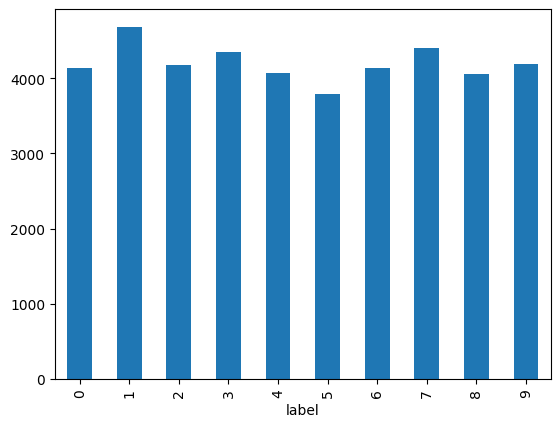

In [34]:
data['label'].value_counts().sort_index().plot(kind='bar')

In [35]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

In [41]:
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

X_dev = X_dev / 255.
X_train = X_train / 255.

|        | img1 | img2 | img3 |
|--------|------|------|------|
| label  | 1    | 0    | 4    |
| p0     | 0    | 0    | 1    |
| p1     | 0    | 3    | 0    |
| p2     | 5    | 0    | 0    |
| ...    | ...  | ...  | ...  |
| p783   | 0    | 0    | 2    |

data (42000 rows)

↓ shuffle

0–999      → dev set
1000–end   → training set

Image (784 pixels)
        ↓
[Neuron 1] → uses 784 weights
[Neuron 2] → uses different 784 weights
...
[Neuron 10]

In [42]:
X_train[:,0].shape

(784,)

| Variable | Meaning                 |
| -------- | ----------------------- |
| Z1       | raw hidden values       |
| A1       | activated hidden values |
| Z2       | raw output scores       |
| A2       | final probabilities     |


In [43]:
import numpy as np

def init_params():
    W1 = np.random.randn(10, 784) * 0.01
    b1 = np.zeros((10, 1))
    W2 = np.random.randn(10, 10) * 0.01
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2


def ReLU(Z):
    return np.maximum(Z, 0)


def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)


def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def ReLU_deriv(Z):
    return Z > 0


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T


def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    return W1, b1, W2, b2


def get_predictions(A2):
    return np.argmax(A2, axis=0)


def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size


def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 10 == 0:
            predictions = get_predictions(A2)
            print("Iteration:", i)
            print("Accuracy:", get_accuracy(predictions, Y))

    return W1, b1, W2, b2

In [44]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [45]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)


Iteration:  0
[9 2 7 ... 7 9 1] [4 8 6 ... 9 3 6]
0.11126829268292683
Iteration:  10
[1 1 7 ... 1 1 1] [4 8 6 ... 9 3 6]
0.13165853658536586
Iteration:  20
[1 1 7 ... 1 1 1] [4 8 6 ... 9 3 6]
0.14704878048780487
Iteration:  30
[1 1 7 ... 7 1 1] [4 8 6 ... 9 3 6]
0.18958536585365854
Iteration:  40
[7 1 7 ... 7 1 1] [4 8 6 ... 9 3 6]
0.2127560975609756
Iteration:  50
[7 1 7 ... 7 1 7] [4 8 6 ... 9 3 6]
0.24097560975609755
Iteration:  60
[7 2 7 ... 7 2 7] [4 8 6 ... 9 3 6]
0.26509756097560977
Iteration:  70
[7 2 7 ... 7 2 2] [4 8 6 ... 9 3 6]
0.28082926829268295
Iteration:  80
[7 2 2 ... 7 2 2] [4 8 6 ... 9 3 6]
0.3188780487804878
Iteration:  90
[7 2 2 ... 7 2 2] [4 8 6 ... 9 3 6]
0.38321951219512196
Iteration:  100
[9 2 6 ... 7 2 6] [4 8 6 ... 9 3 6]
0.5036341463414634
Iteration:  110
[9 2 6 ... 9 3 6] [4 8 6 ... 9 3 6]
0.5937560975609756
Iteration:  120
[9 2 6 ... 9 3 6] [4 8 6 ... 9 3 6]
0.6411219512195122
Iteration:  130
[9 2 6 ... 9 3 6] [4 8 6 ... 9 3 6]
0.6836341463414635
Iteration

In [50]:
from matplotlib import pyplot as plt


In [64]:
import matplotlib.pyplot as plt

def test_predictions(indices, W1, b1, W2, b2, X, Y):
    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(indices):
        _, _, _, A2 = forward_prop(W1, b1, W2, b2, X[:, idx].reshape(-1, 1))
        pred = np.argmax(A2)

        img = X[:, idx].reshape(28, 28)

        plt.subplot(1, len(indices), i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"P:{pred}\nT:{Y[idx]}")
        plt.axis('off')

    plt.show()

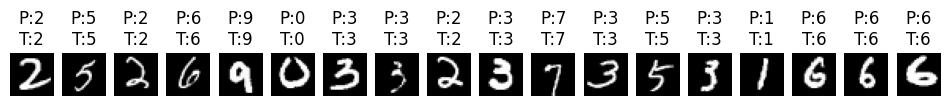

In [66]:
test_predictions(
    list(range(18)),   # 0 to 8
    W1, b1, W2, b2,
    X_dev,
    Y_dev
)